In [1]:
import jax
from jax import flatten_util, vmap, grad 
import jax.numpy as jnp
import jax.random as jr

from scipy.signal import savgol_filter
from scipy.interpolate import CubicSpline

import matplotlib.pyplot as plt
from functools import partial
import optax
from helper_fns_general import sample_gaussian_mixture, normalize_samples, CD1_gradient, setup_score_matching_loss_per_batch, run_optimization, setup_overdamped_SDE, solve_SDE, sample_forward_process, setup_MLE_loss_per_batch, setup_MLE_gradient_per_batch
from plotting_fns import plot_energy_and_distributions, plot_parameter_evolution, get_best_params
jax.config.update("jax_enable_x64", True)

CUDA backend failed to initialize: Unable to use CUDA because of the following issues with CUDA components:
Outdated cuDNN installation found.
Version JAX was built against: 8907
Minimum supported: 9100
Installed version: 8907
The local installation version must be no lower than 9100..(Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


### Generate samples from a Gaussian mixture

In [2]:
import numpy as np
# Load the saved .npy file
data_np = np.load("data/MNIST/MNIST_0_1_8x8pix/mnist_0_1_8x8pix.npy")

# Optionally convert to a JAX array
images_flat_raw = jnp.array(data_np)
n_samples = images_flat_raw.shape[0]
print("Data shape:", images_flat_raw.shape)

Data shape: (12665, 64)


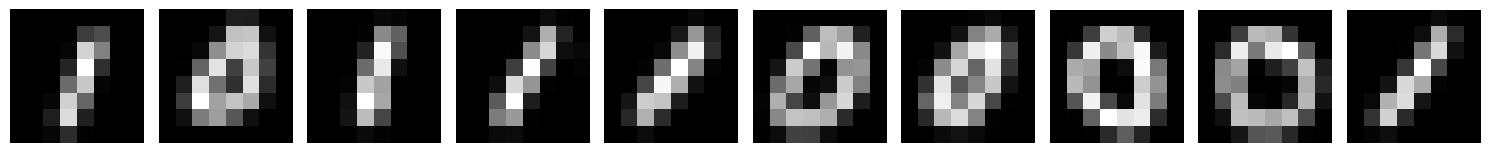

In [3]:
images = images_flat_raw.reshape(-1, 8, 8)
# Plot a few examples
num_examples = 10  # number of examples to display
fig, axes = plt.subplots(1, num_examples, figsize=(15, 2))

for i in range(num_examples):
    # Remove channel dimension if it exists (i.e., converting 8x8x1 to 8x8)
    img = images[i]
    if img.shape[-1] == 1:
        img = img.squeeze(-1)
    
    axes[i].imshow(np.array(img), cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [4]:
mean = jnp.mean(images_flat_raw)  # This calculates mean over all samples and pixels
std = jnp.std(images_flat_raw)    # This calculates std over all samples and pixels
images_flat = (images_flat_raw - mean) / std  # This normalizes the data

### Plot samples and marginal distributions

In [5]:
key = jr.PRNGKey(0)

key, subkey = jr.split(key)
t_forward = 1.0
sigma_final = 1.0
samples_t = sample_forward_process(t_forward, n_samples, D=1, sigma_final=sigma_final, samples0=images_flat, key=subkey)

In [6]:
samples_t.shape

(12665, 64)

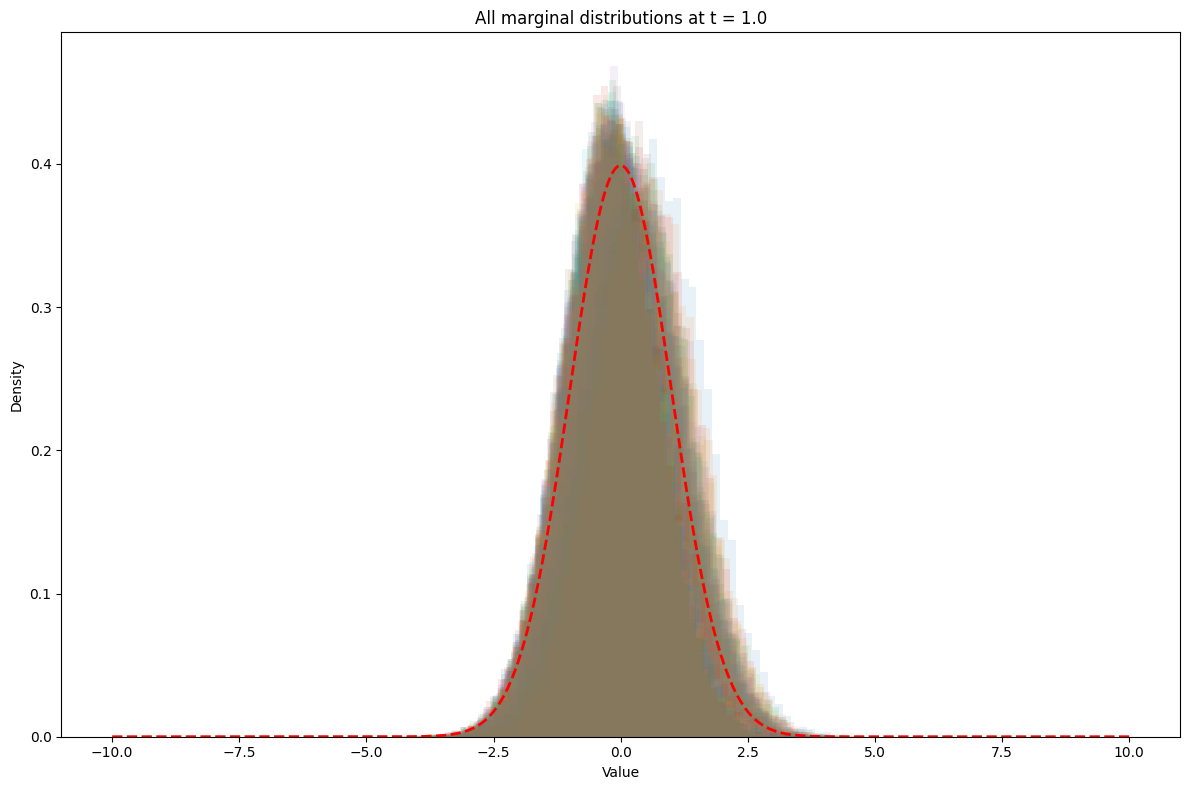

In [7]:
# Create a single plot for all marginal distributions
fig, ax = plt.subplots(figsize=(12, 8))

# Plot histogram for each dimension
for i in range(64):
    ax.hist(samples_t[:, i], bins=50, density=True, alpha=0.1, label=f'Dim {i}')

# Add Gaussian N(0,1) for comparison
x = jnp.linspace(-10, 10, 1000)
gaussian_pdf = (1 / jnp.sqrt(2 * jnp.pi*sigma_final**2)) * jnp.exp(-0.5 * x**2/sigma_final**2)
ax.plot(x, gaussian_pdf, 'r--', linewidth=2, label='Gaussian N(0,1)')

ax.set_title(f'All marginal distributions at t = {t_forward}')
ax.set_xlabel('Value')
ax.set_ylabel('Density')
# ax.legend() # Commenting out as 64 legend entries would be too cluttered

plt.tight_layout()
plt.show()

### Define energy function of duffing oscillator network

In [8]:
def energy_self_oscillator(x, k_lin, k_duff):
    return 1 / 2 * k_lin * x**2 + 1 / 4 * k_duff * x**4

def energy_self_network(x, k_lin, k_duff):
    return jnp.sum(vmap(energy_self_oscillator)(x, k_lin, k_duff))


def energy_coupling_pair(x, y, c_lin, c_optomech):
    return c_lin * x * (x - y) + c_lin * y * (y - x) + c_optomech * (x**2) * y

def energy_coupling_network(x, c_lin, c_optomech, connectivity):
    # get contribution to total energy from each pair of oscillators
    
    def _coupling_energy_pair(x, c_lin, c_optomech, pair):
        # get energy of one pair of oscillators
        i, j = pair
        return energy_coupling_pair(x[i], x[j], c_lin, c_optomech)

    # get energy of all pairs of oscillators
    return jnp.sum(
        vmap(_coupling_energy_pair, in_axes=(None, 0, 0, 0))(
            x, c_lin, c_optomech, connectivity
        )
    )


def _energy_duffing_network(x, k_lin, k_duff, c_lin, c_optomech, connectivity, k_b=1., T=1.):
    # returns energy of network of oscillators given input parameters
    return (
        energy_self_network(x, k_lin, k_duff) +
        energy_coupling_network(x, c_lin, c_optomech, connectivity)
    ) / (k_b * T)

Number of connections: 112
Connectivity matrix shape: (112, 2)

First few connections:
[[ 0  1]
 [ 0  8]
 [ 1  2]
 [ 1  9]
 [ 2  3]
 [ 2 10]
 [ 3  4]
 [ 3 11]
 [ 4  5]
 [ 4 12]
 [ 5  6]
 [ 5 13]
 [ 6  7]
 [ 6 14]
 [ 7 15]
 [ 8  9]
 [ 8 16]
 [ 9 10]
 [ 9 17]
 [10 11]
 [10 18]
 [11 12]
 [11 19]
 [12 13]
 [12 20]
 [13 14]
 [13 21]
 [14 15]
 [14 22]
 [15 23]
 [16 17]
 [16 24]
 [17 18]
 [17 25]
 [18 19]
 [18 26]
 [19 20]
 [19 27]
 [20 21]
 [20 28]
 [21 22]
 [21 29]
 [22 23]
 [22 30]
 [23 31]
 [24 25]
 [24 32]
 [25 26]
 [25 33]
 [26 27]
 [26 34]
 [27 28]
 [27 35]
 [28 29]
 [28 36]
 [29 30]
 [29 37]
 [30 31]
 [30 38]
 [31 39]
 [32 33]
 [32 40]
 [33 34]
 [33 41]
 [34 35]
 [34 42]
 [35 36]
 [35 43]
 [36 37]
 [36 44]
 [37 38]
 [37 45]
 [38 39]
 [38 46]
 [39 47]
 [40 41]
 [40 48]
 [41 42]
 [41 49]
 [42 43]
 [42 50]
 [43 44]
 [43 51]
 [44 45]
 [44 52]
 [45 46]
 [45 53]
 [46 47]
 [46 54]
 [47 55]
 [48 49]
 [48 56]
 [49 50]
 [49 57]
 [50 51]
 [50 58]
 [51 52]
 [51 59]
 [52 53]
 [52 60]
 [53 54]
 [53

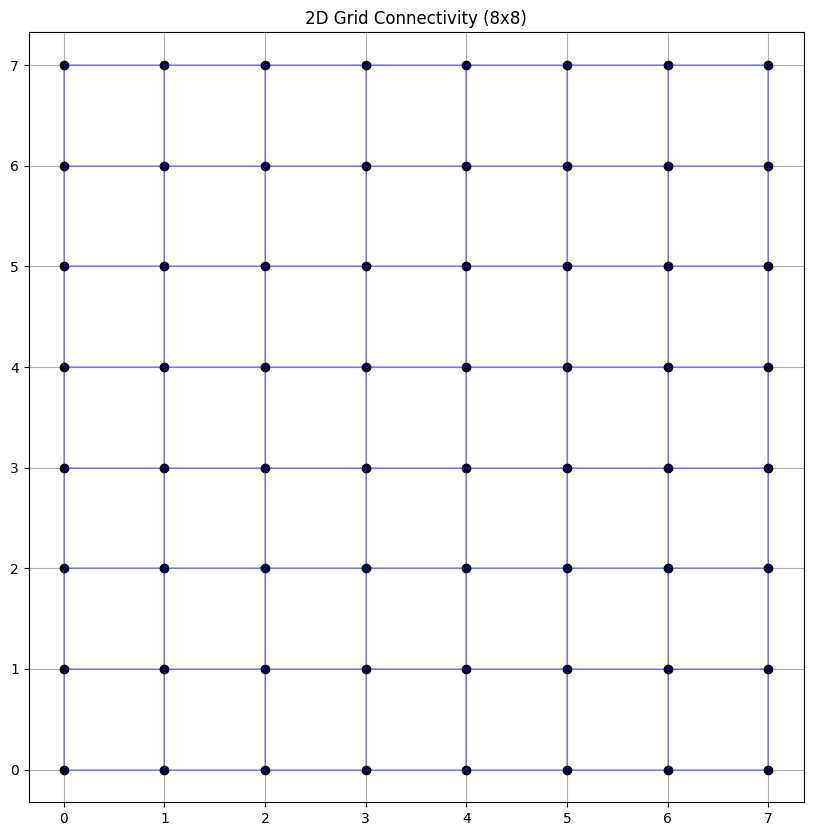

Number of connections: 112
Connectivity matrix shape: (112, 2)


In [9]:
N_osc = 64


# Create 2D grid connectivity for 8x8 oscillators
def create_2d_grid_connectivity(grid_size=jnp.sqrt(N_osc)):
    connections = []
    
    for i in range(grid_size):
        for j in range(grid_size):
            current = i * grid_size + j
            
            # Connect to right neighbor
            if j < grid_size - 1:
                connections.append([current, current + 1])
            
            # Connect to bottom neighbor
            if i < grid_size - 1:
                connections.append([current, current + grid_size])
    
    return jnp.array(connections)

def visualize_connectivity(connectivity, grid_size=8):
    """
    Visualize the connectivity pattern of the grid.
    
    Args:
        connectivity (jnp.ndarray): Connectivity matrix
        grid_size (int): Size of the square grid
    """
    import matplotlib.pyplot as plt
    
    plt.figure(figsize=(10, 10))
    
    # Plot oscillators
    for i in range(grid_size):
        for j in range(grid_size):
            plt.plot(j, i, 'ko')
    
    # Plot connections
    for conn in connectivity:
        i1, j1 = divmod(conn[0], grid_size)
        i2, j2 = divmod(conn[1], grid_size)
        plt.plot([j1, j2], [i1, i2], 'b-', alpha=0.3)
    
    plt.grid(True)
    plt.axis('equal')
    plt.title(f'2D Grid Connectivity ({grid_size}x{grid_size})')
    plt.show()

# Create the connectivity matrix for 8x8 grid
connectivity = create_2d_grid_connectivity(grid_size=8)

# Print the number of connections
print(f"Number of connections: {len(connectivity)}")
print(f"Connectivity matrix shape: {connectivity.shape}")

# Example of first few connections
print("\nFirst few connections:")
print(connectivity)

visualize_connectivity(connectivity)
num_connections = connectivity.shape[0]
print(f"Number of connections: {num_connections}")
print(f"Connectivity matrix shape: {connectivity.shape}")


### Define initial parameters

In [10]:

k_lin_0 = -1.*jnp.ones(N_osc)
k_duff_0 = jnp.ones(N_osc)
c_lin_0 = jnp.zeros(num_connections)
c_optomech_0 = jnp.zeros(num_connections)
# connectivity = jnp.array([[0, 1]])

args_initial = (k_lin_0, k_duff_0, c_lin_0, c_optomech_0)

flattened_args_initial, unflatten = flatten_util.ravel_pytree(args_initial)


### Bringe energy into correct form

In [11]:
def energy_duffing_network(x, flattened_args, connectivity):
    k_lin, k_duffing, c_lin, c_optomech = unflatten(flattened_args)
    return _energy_duffing_network(x, k_lin, k_duffing, c_lin, c_optomech, connectivity)
energy_fn = lambda x, flattened_args: energy_duffing_network(x, flattened_args, connectivity)

### Plot initial energy landscape

In [12]:
# Choose training method
training_method = "SM"  # Options: "SM" (Score Matching), "CD1" (Contrastive Divergence), "MLE" (Maximum Likelihood)

# Setup loss and gradient functions based on selected method
if training_method == "SM":
    loss_fn_per_batch = setup_score_matching_loss_per_batch(energy_fn)
    gradient_fn_per_batch = None
    maximize = False
elif training_method == "CD1":
    loss_fn_per_batch = setup_score_matching_loss_per_batch(energy_fn)
    gradient_fn_per_batch = lambda flattened_args, batch: -CD1_gradient(energy_fn, batch, flattened_args, dt=0.001, D=1, key=key, num_noise_samples=1000)
    maximize = False
elif training_method == "MLE":
    loss_fn_per_batch = setup_MLE_loss_per_batch(energy_fn)
    gradient_fn_per_batch = setup_MLE_gradient_per_batch(energy_fn)
    maximize = True
else:
    raise ValueError(f"Unknown training method: {training_method}. Choose from 'SM', 'CD1', or 'MLE'.")

In [13]:
# Define filename for saving/loading parameters
n_time_steps = 50
# forward_time_pts = jnp.linspace(0., t_forward, n_time_steps)
forward_time_pts = jnp.exp(jnp.linspace(jnp.log(1e-6), jnp.log(t_forward), n_time_steps))
forward_time_pts = jnp.concatenate([jnp.array([0.]),forward_time_pts])

In [14]:
forward_time_pts

Array([0.00000000e+00, 1.00000000e-06, 1.32571137e-06, 1.75751062e-06,
       2.32995181e-06, 3.08884360e-06, 4.09491506e-06, 5.42867544e-06,
       7.19685673e-06, 9.54095476e-06, 1.26485522e-05, 1.67683294e-05,
       2.22299648e-05, 2.94705170e-05, 3.90693994e-05, 5.17947468e-05,
       6.86648845e-05, 9.10298178e-05, 1.20679264e-04, 1.59985872e-04,
       2.12095089e-04, 2.81176870e-04, 3.72759372e-04, 4.94171336e-04,
       6.55128557e-04, 8.68511374e-04, 1.15139540e-03, 1.52641797e-03,
       2.02358965e-03, 2.68269580e-03, 3.55648031e-03, 4.71486636e-03,
       6.25055193e-03, 8.28642773e-03, 1.09854114e-02, 1.45634848e-02,
       1.93069773e-02, 2.55954792e-02, 3.39322177e-02, 4.49843267e-02,
       5.96362332e-02, 7.90604321e-02, 1.04811313e-01, 1.38949549e-01,
       1.84206997e-01, 2.44205309e-01, 3.23745754e-01, 4.29193426e-01,
       5.68986603e-01, 7.54312006e-01, 1.00000000e+00], dtype=float64)

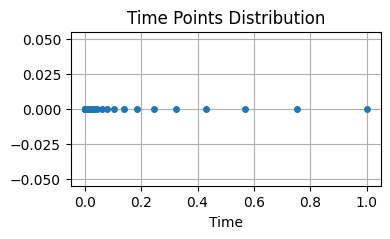

In [15]:
plt.figure(figsize=(4, 2))
plt.plot(forward_time_pts, jnp.zeros_like(forward_time_pts), 'o', markersize=4)
plt.xlabel('Time')
plt.ylabel('')
plt.title('Time Points Distribution')
plt.grid(True)
plt.show()

In [16]:
load_param_histories = True    
learning_rate = 10.
n_epochs_start = 5000
n_epochs_after_start = 1000
batch_size = 2*128
filename = f"out/MNIST/Labels_1_2_resol_8x8/{training_method}/params_history_means_t_forward_{t_forward}_n_timestes_{n_time_steps}_n_epochs_start_{n_epochs_start}_n_epochs_{n_epochs_after_start}_batch_size_{batch_size}_learning_rate_{learning_rate}.npy"
if load_param_histories:
    # Load existing parameters
    params_history_all_t = jnp.load(filename)
else:
    # Setup optimization parameters
    mask = jnp.ones(flattened_args_initial.shape[0])


    # Plotting parameters
    plot_steps = True  # Flag to control whether to plot during optimization
    plot_slice = 10     # Plot every nth step


    # Initialize storage for parameters at each time step
    params_history_all_t = []
    current_params = flattened_args_initial

    # Loop over time points
    for t_idx, t_forward in enumerate(forward_time_pts):
        print
        if t_idx == 0: 
            n_epochs = n_epochs_start
        else:
            n_epochs = n_epochs_after_start
        print(f"Optimization for time {t_forward} with num epochs: {n_epochs}")
        
        # Generate samples at current time
        key, subkey = jr.split(key)
        samples_t = sample_forward_process(
            t_forward,n_samples, D=1, sigma_final=sigma_final, samples0=images_flat, key=subkey)
        
        # Perform optimization starting from previous best parameters
        key, subkey = jr.split(key)
        
        params_history, loss_history = run_optimization(
            loss_fn_per_batch=loss_fn_per_batch,
            params_initial=current_params,
            samples=samples_t,
            mask=mask,
            gradient_fn_per_batch=gradient_fn_per_batch,
            key=subkey,
            batch_size=batch_size,
            learning_rate=learning_rate,
            n_epochs=n_epochs,
            maximize=maximize
        )
        
        _, best_params, _ = get_best_params(params_history, loss_history, maximize=maximize)
        k_lin_best, k_duff_best, c_lin_best, c_optomech_best = unflatten(best_params)
        current_params, _ = flatten_util.ravel_pytree(best_params)
        params_history_all_t.append(current_params)
        
        if plot_steps:
            if t_idx % plot_slice == 0:
                # Plot optimization progress
                plot_parameter_evolution(
                    params_history=params_history,
                    loss_history=loss_history,
                    unflatten=unflatten,
                    N_osc=N_osc,
                    N_connections=num_connections,
                    slicing=10,
                    title=f"{training_method} (t = {t_forward:.3f})",
                    maximize=maximize,
                    labels_on=False
                )
                # Plot current energy landscape
                # plot_energy_and_distributions(
                #     energy_fn=energy_fn,
                #     param_list=[current_params],
                #     samples=samples_t,
                #     x1_range=(-1, 1),
                #     x2_range=(-1, 1),
                #     n_points=30,
                #     titles=[f"t = {t_forward:.3f}"],
                #     fontsize=16,
                #     sample_stride=1,
                #     suptitle=f"Energy Landscape at t = {t_forward:.3f}"
                # )
            
    # Convert params_history_all_t to array for easier analysis
    params_history_all_t = jnp.array(params_history_all_t)
    jnp.save(filename, params_history_all_t)


### Smoothen and interpolate parameter evolution

In [17]:
def smooth_parameters(params, window_lengths = [31, 31, 31, 31, 31, 31], poly_orders = [3, 3, 3, 3, 3, 3]):
    """
    Smooths multiple parameter trajectories using Savitzky-Golay filter
    
    Args:
        params: Array of shape (n_timesteps, n_params) containing parameter trajectories
        window_lengths: List/array of window lengths for each parameter dimension
        poly_orders: List/array of polynomial orders for each parameter dimension
    
    Returns:
        Array of shape (n_timesteps, n_params) containing smoothed parameter trajectories
    """
    n_params = params.shape[1]
    smoothed = []
    
    for i in range(n_params):
        # Ensure window length is odd and valid
        window_length = min(window_lengths[i], len(params) - (1 - len(params) % 2))
        if window_length % 2 == 0:
            window_length -= 1
            
        # Smooth using Savitzky-Golay filter
        smoothed.append(savgol_filter(params[:, i], window_length, poly_orders[i]))
    
    return jnp.column_stack(smoothed)


def interpolate_parameters(params, time_points):
    """
    Interpolates parameter trajectories using jnp.interp in a vectorized fashion.

    Args:
        params: Array of shape (n_timesteps, n_params) containing parameter trajectories.
        time_points: 1D array of shape (n_timesteps,) corresponding to the time points.

    Returns:
        A function that takes time points `t` (scalar or 1D array) and returns
        the interpolated parameters. For scalar `t`, the result is shape (n_params,);
        for vector `t`, the result is shape (len(t), n_params).
    """
    
    def _interpolator(t):
        # Transpose params to shape (n_params, n_timesteps) so that each row is a trajectory.
        # Use vmap to apply jnp.interp over each parameter trajectory.
        interpolated = jax.vmap(lambda param: jnp.interp(t, time_points, param))(params.T)
        # If t is an array, jnp.interp returns an array for each parameter, resulting in a
        # (n_params, len(t)) array. Transpose it so that each row corresponds to a time point.
        if jnp.ndim(t) > 0:
            return interpolated.T
        return interpolated

    return _interpolator


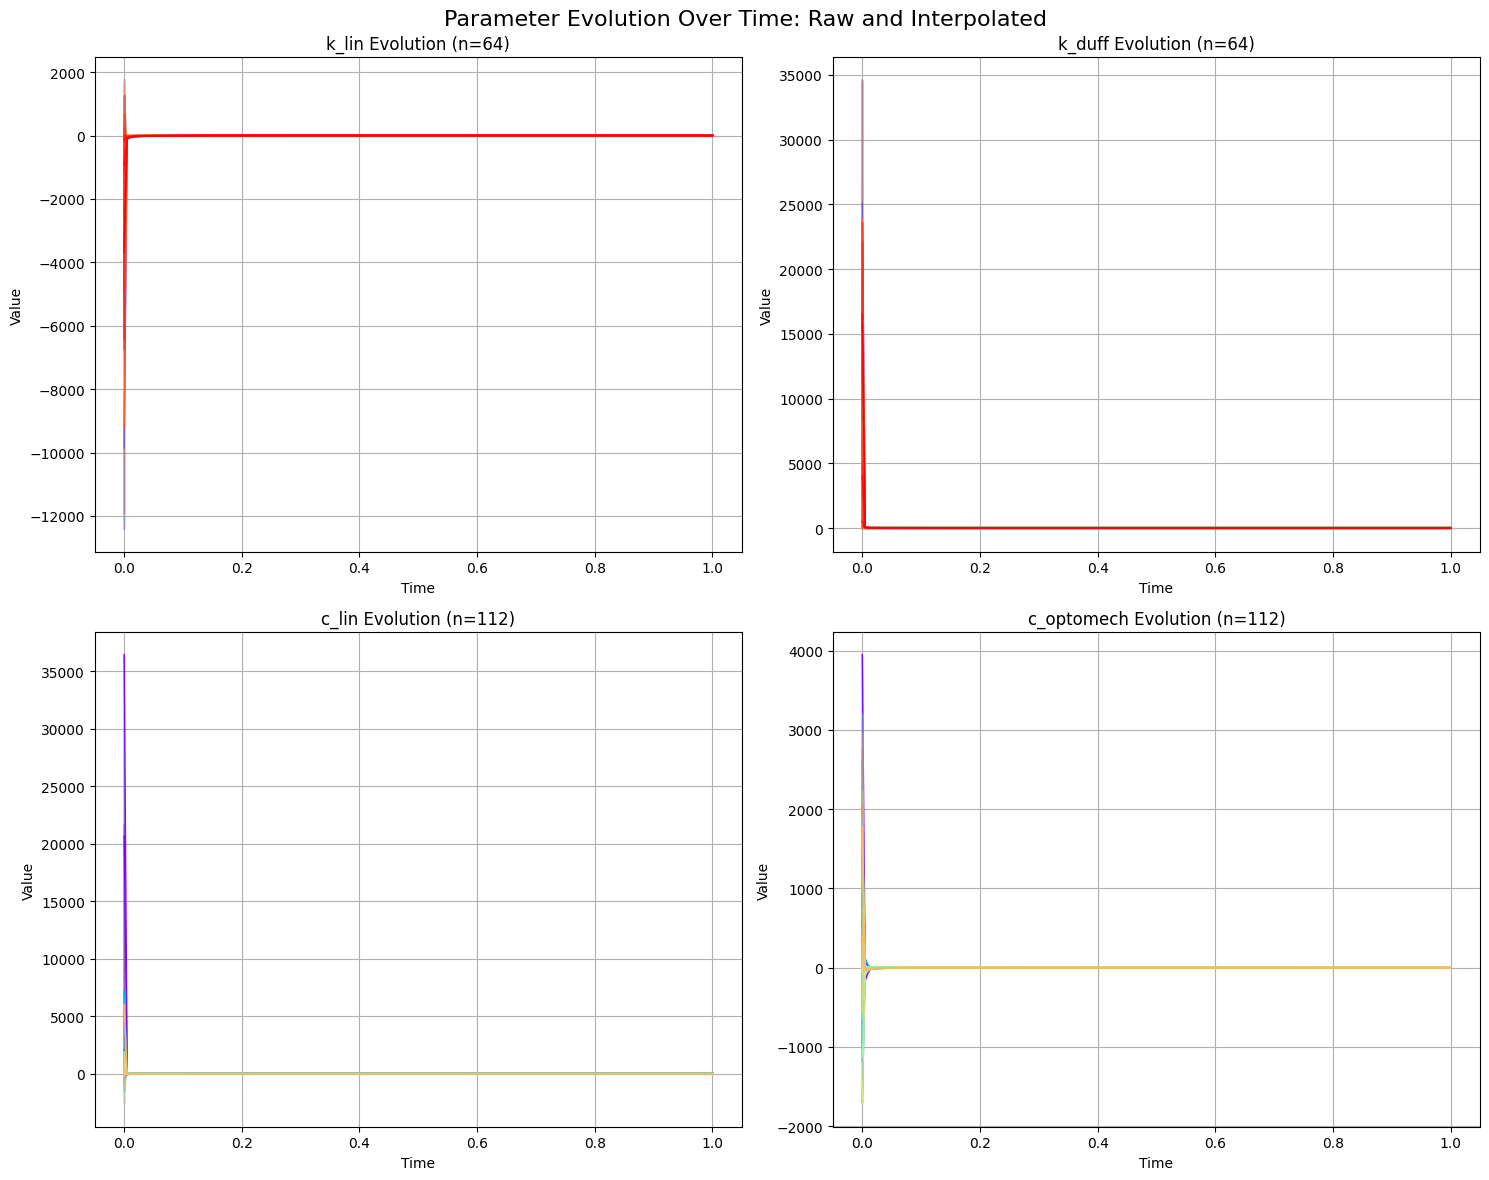

In [18]:
use_smoothed_params = False
if use_smoothed_params:
    # First smooth the parameters
    smoothed_params = smooth_parameters(params_history_all_t)
    # Get interpolator function
    params_interpolator = interpolate_parameters(smoothed_params, forward_time_pts)
else:
    # Get interpolator function
    params_interpolator = interpolate_parameters(params_history_all_t, forward_time_pts)

# Then interpolate the smoothed parameters
time_eval = jnp.linspace(forward_time_pts[0],forward_time_pts[-1],200)
# interpolated_params = interpolate_parameters(smoothed_params, forward_time_pts, time_dense)
interpolated_params = params_interpolator(time_eval)

# Create figure
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Parameter Evolution Over Time: Raw and Interpolated', fontsize=16)

# Plot settings
param_names = ['k_lin', 'k_duff', 'c_lin', 'c_optomech']
axes = [ax1, ax2, ax3, ax4]
colors = plt.cm.rainbow(np.linspace(0, 1, N_osc))  # Create color map based on number of oscillators

# Define parameter slices
param_slices = [
    slice(0, N_osc),           # k_lin
    slice(N_osc, 2*N_osc),     # k_duff
    slice(2*N_osc, 2*N_osc + num_connections),    # c_lin
    slice(2*N_osc + num_connections, 2*N_osc + 2*num_connections)  # c_optomech
]

# Plot for each parameter type
for ax, param_name, param_slice in zip(axes, param_names, param_slices):
    num_params = param_slice.stop - param_slice.start
    
    # Plot each parameter in the slice
    for i in range(num_params):
        param_idx = param_slice.start + i
        # Plot raw data (lighter)
        ax.plot(forward_time_pts, params_history_all_t[:, param_idx], 
                color=colors[i % len(colors)], alpha=0.3)
        
        # Plot interpolated data (darker)
        ax.plot(time_eval, interpolated_params[:, param_idx], 
                color=colors[i % len(colors)], linewidth=1)
    
    ax.set_title(f'{param_name} Evolution (n={num_params})')
    ax.set_xlabel('Time')
    ax.set_ylabel('Value')
    ax.grid(True)

plt.tight_layout()
plt.show()

### Run reverse SDE:

In [19]:
forward_params = jnp.zeros_like(flattened_args_initial)
forward_params = forward_params.at[0].set(1.)
forward_params = forward_params.at[1].set(1.)
params_interpolator_reverse_plus_linear = lambda t: 2*params_interpolator(t_forward - t) - 1/sigma_final**2 * forward_params

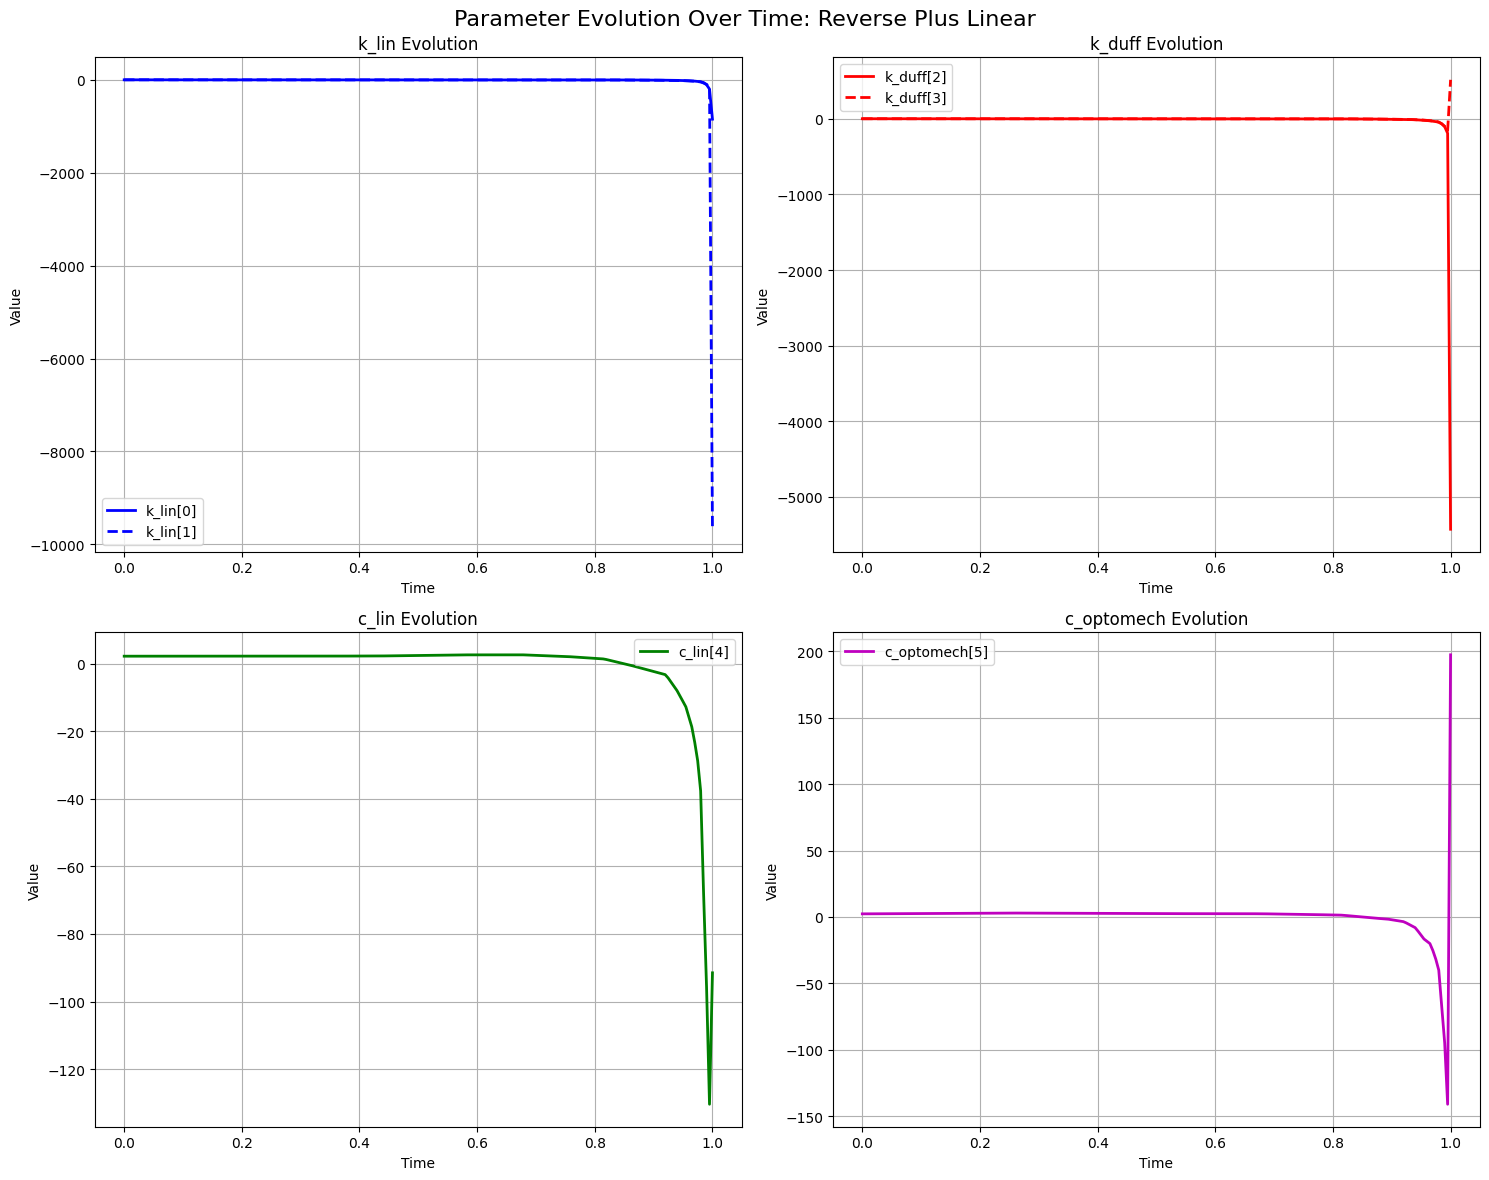

In [20]:
# Create time points for evaluation
time_eval = jnp.linspace(0, t_forward, 200)

# Get parameters at each time point
params_over_time = jnp.vstack([params_interpolator_reverse_plus_linear(t) for t in time_eval])

# Create figure
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Parameter Evolution Over Time: Reverse Plus Linear', fontsize=16)

# Plot settings
param_names = ['k_lin', 'k_duff', 'c_lin', 'c_optomech']
axes = [ax1, ax2, ax3, ax4]
colors = ['b', 'r', 'g', 'm']
param_indices = [(0,1), (2,3), (4,), (5,)]

# Plot for each parameter type
for ax, param_name, color, indices in zip(axes, param_names, colors, param_indices):
    for idx, style in zip(indices, ['-', '--']):
        ax.plot(time_eval, params_over_time[:, idx], color + style, linewidth=2,
                label=f'{param_name}[{idx}]')
    
    ax.set_title(f'{param_name} Evolution')
    ax.set_xlabel('Time')
    ax.set_ylabel('Value')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

In [24]:
# Setup SDE functions
drift_fn, diffusion_fn = setup_overdamped_SDE(energy_fn, params_interpolator_reverse_plus_linear, N_osc, time_dependent_parms=True)

In [25]:
t0 = 0.0
t1 = t_forward
ts = jnp.linspace(t0, t1, 10)
dt0 = ts[1] - ts[0]

# Generate multiple initial states
# n_trajectories = 2000
# key, subkey = jr.split(key)
# initial_states = sample_forward_process(t_forward, n_trajectories, D=1, samples0=samples_0, key=subkey, diffusion_rate=diffusion_rate)
# Sample initial conditions from N(0, I)
n_trajectories = 2  # or any other number of trajectories you need
n_dimensions = 2  # assuming 2D, adjust as necessary
key, subkey = jr.split(key)
initial_states = jr.normal(subkey, (n_trajectories, n_dimensions))

# Generate a key for each initial condition
key, subkey = jr.split(key)
keys_brownian = jr.split(subkey, n_trajectories)

# Vectorize solve_SDE across both initial states and keys
vectorized_solve_SDE = vmap(
    lambda init_state, key_b: solve_SDE(
        drift_fn, 
        diffusion_fn, 
        init_state,
        key_b, 
        t0, 
        t1, 
        ts.shape[0], 
        dt0
    ),
    in_axes=(0, 0)
)


# Run SDE for all initial states at once
solutions = vectorized_solve_SDE(initial_states, keys_brownian)
all_trajectories = solutions.ys  # Shape: (n_trajectories, n_timesteps, 2)
final_states = all_trajectories[:, -1, :]  # Shape: (n_trajectories, 2)


ValueError: `terms` must be a PyTree of `AbstractTerms` (such as `ODETerm`), with structure diffrax._term.MultiTerm[tuple[diffrax._term.ODETerm, diffrax._term.AbstractTerm[typing.Any, diffrax._custom_types.AbstractSpaceTimeLevyArea]]]

In [ ]:
solve_time = 0.0
drift_fn, diffusion_fn = setup_overdamped_SDE(energy_fn, params_interpolator(solve_time), N_osc,time_dependent_parms=False)
t0 = 0.0
t1 = 10 
ts = jnp.linspace(t0, t1, 1000)
dt0 = ts[1] - ts[0]
initial_state = jnp.array([-.5,0.])
key_equilibrium = jr.PRNGKey(111111)
solution_direct = solve_SDE(drift_fn, diffusion_fn, initial_state,key_equilibrium, t0, t1, ts.shape[0], dt0)
sde_samples_direct = solution_direct.ys


In [ ]:
param_list = [params_interpolator(solve_time)]
titles = ["Solution from reverse process"]
plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=final_states,
    sample_stride=1,
    x1_range=(-1.5, 1.5),    
    x2_range=(-1.5, 1.5),    
    n_points=50,    
    titles=titles,       
    figsize=None,    
    fontsize=12,         
    suptitle="Energy landscape with samples from reverse process"  
)

In [ ]:
param_list = [params_interpolator(solve_time)]
titles = ["Solution from direct integration"]
plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=sde_samples_direct,
    sample_stride=1,
    x1_range=(-1.5, 1.5),    
    x2_range=(-1.5, 1.5),    
    n_points=50,    
    titles=titles,       
    figsize=None,    
    fontsize=12,         
    suptitle="Energy landscape with samples from direct integration"  
)

In [ ]:
# Set font sizes
SMALL_SIZE = 16
MEDIUM_SIZE = 18
BIGGER_SIZE = 22

# Create 2x2 subplot
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Final States vs Equilibrium Sampling Distributions', fontsize=BIGGER_SIZE)

# Top row: Initial and Final states
ax1.hist(initial_states[:, 0], bins=30, alpha=0.5, density=True, label='Initial', color='blue')
ax1.hist(final_states[:, 0], bins=30, alpha=0.5, density=True, label='Final', color='red')
ax2.hist(initial_states[:, 1], bins=30, alpha=0.5, density=True, label='Initial', color='blue')
ax2.hist(final_states[:, 1], bins=30, alpha=0.5, density=True, label='Final', color='red')

# Bottom row: Equilibrium sampling in green
ax3.hist(sde_samples_direct[:, 0], bins=30, alpha=0.5, density=True, label='Equilibrium sampling', color='green')
ax4.hist(sde_samples_direct[:, 1], bins=30, alpha=0.5, density=True, label='Equilibrium sampling', color='green')

# Add exact marginal Gaussians to all plots
x = jnp.linspace(-1.5, 1.5, 1000)

# Plot marginals for each subplot separately with correct dimension
for ax, dim in [(ax1, 0), (ax2, 1), (ax3, 0), (ax4, 1)]:
    marginal = jnp.zeros_like(x)
    for w, m, c in zip(weights, means, covs):
        mean = m[dim]
        std = jnp.sqrt(c[dim, dim])
        marginal += w * jnp.exp(-0.5 * ((x - mean) / std) ** 2) / (std * jnp.sqrt(2 * jnp.pi))
    ax.plot(x, marginal, '--k', linewidth=2, label=f'Target marginal {["X1", "X2"][dim]}')
    
    # Increase font sizes for tick labels
    ax.tick_params(axis='both', which='major', labelsize=SMALL_SIZE)

# Set titles and labels with increased font sizes
ax1.set_title('Initial and Final X1 Distribution', fontsize=MEDIUM_SIZE)
ax1.set_xlabel('X1', fontsize=MEDIUM_SIZE)
ax1.set_ylabel('Density', fontsize=MEDIUM_SIZE)
ax1.legend(fontsize=SMALL_SIZE)

ax2.set_title('Initial and Final X2 Distribution', fontsize=MEDIUM_SIZE)
ax2.set_xlabel('X2', fontsize=MEDIUM_SIZE)
ax2.set_ylabel('Density', fontsize=MEDIUM_SIZE)
ax2.legend(fontsize=SMALL_SIZE)

ax3.set_title('Equilibrium Sampling X1', fontsize=MEDIUM_SIZE)
ax3.set_xlabel('X1', fontsize=MEDIUM_SIZE)
ax3.set_ylabel('Density', fontsize=MEDIUM_SIZE)
ax3.legend(fontsize=SMALL_SIZE)

ax4.set_title('Equilibrium Sampling X2', fontsize=MEDIUM_SIZE)
ax4.set_xlabel('X2', fontsize=MEDIUM_SIZE)
ax4.set_ylabel('Density', fontsize=MEDIUM_SIZE)
ax4.legend(fontsize=SMALL_SIZE)

plt.tight_layout()
plt.show()